In [87]:
import h5py 
import numpy as np
import pandas as pd
import rasterio as rio
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm import tqdm

from geovision.data.usgs import CDL, NLCD, CORINE
from matplotlib.colors import ListedColormap
from geovision.data.spectral_earth import SpectralEarth
from geovision.data.spectral_earth import SpectralEarth_CDL_Segmentation_HDF5 

In [46]:
SpectralEarth.transform('hdf5', 'spectral_earth_cdl')

encoding spectral_earth_cdl: 100%|██████████| 2000/2000 [01:44<00:00, 19.11it/s]


In [ ]:
hist_data: dict[int, int] = dict()
cdl_freq = np.zeros(shape = (255,), dtype = np.int64)

with h5py.File(SpectralEarth.local / "hdf5" / "spectral_earth_cdl.h5") as f:
    for mask in tqdm(f["masks"]):
        for value in mask.flatten().tolist():
            cdl_freq[value] += 1

100%|██████████| 2000/2000 [00:09<00:00, 212.44it/s]


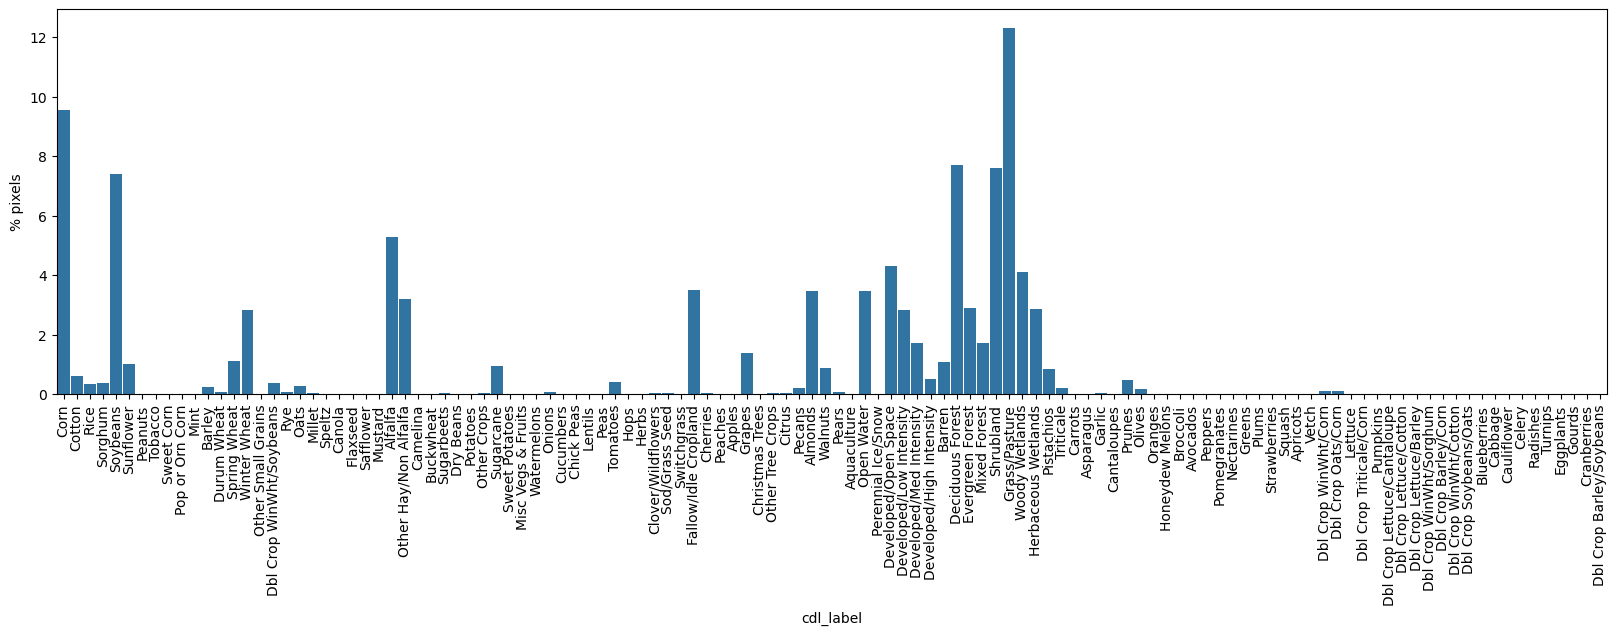

In [41]:
df = pd.DataFrame({"freq": cdl_freq})
df = df[df["freq"] > 0]
df["% pixels"] = (df["freq"] / df["freq"].sum()) * 100
df["cdl_label"] = df.index.map(CDL.classes)

#.sort_values("freq", ascending=False)
#df["cumulative"] = df["freq"].cumsum()

fig, ax = plt.subplots(1,1,figsize = (20, 5))
plt.xticks(rotation=90, ha='center')
sns.barplot(df, x = "cdl_label", y = "% pixels", width=0.9, ax = ax)
fig.savefig(SpectralEarth.local / "imagefolder" / "cdl_pixel_dist.png")

<Axes: xlabel='cdl_label', ylabel='% pixels'>

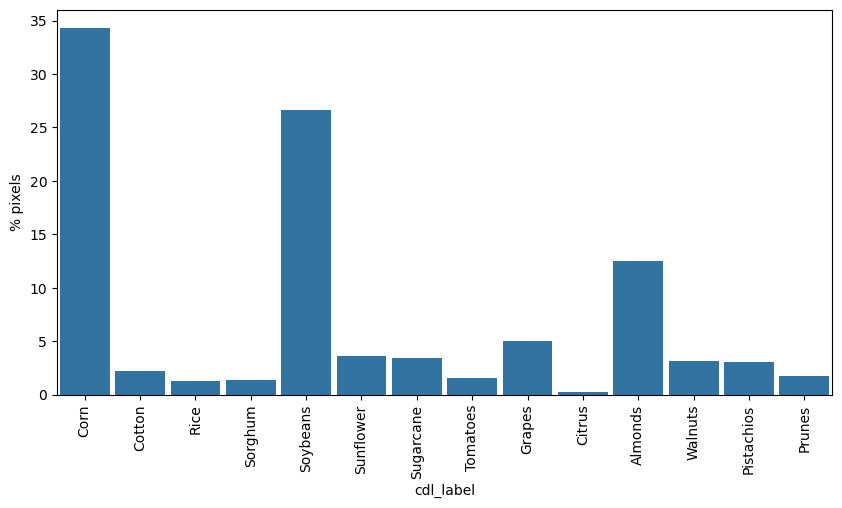

In [ ]:
cdl_df = df[df["cdl_label"].isin(SpectralEarth.cdl_class_str)].copy()
cdl_df["% pixels"] = (cdl_df["freq"] / cdl_df["freq"].sum()) * 100

fig, ax = plt.subplots(1,1,figsize = (10, 5))
plt.xticks(rotation=90, ha='center')
sns.barplot(cdl_df, x = "cdl_label", y = "% pixels", width=0.9, ax = ax)

,freq,% pixels
cdl_label,,
Plums,6129,0.018704
Prunes,156717,0.478262


,freq,% pixels
cdl_label,,
Oranges,10433,0.031839
Citrus,20208,0.061670


,freq,% pixels
cdl_label,,
Sweet Corn,5008,0.015283
Pop or Orn Corn,937,0.002859
Corn,3128413,9.547159


,freq,% pixels
cdl_label,,
Dbl Crop WinWht/Sorghum,1940,0.005920
Sorghum,120782,0.368597


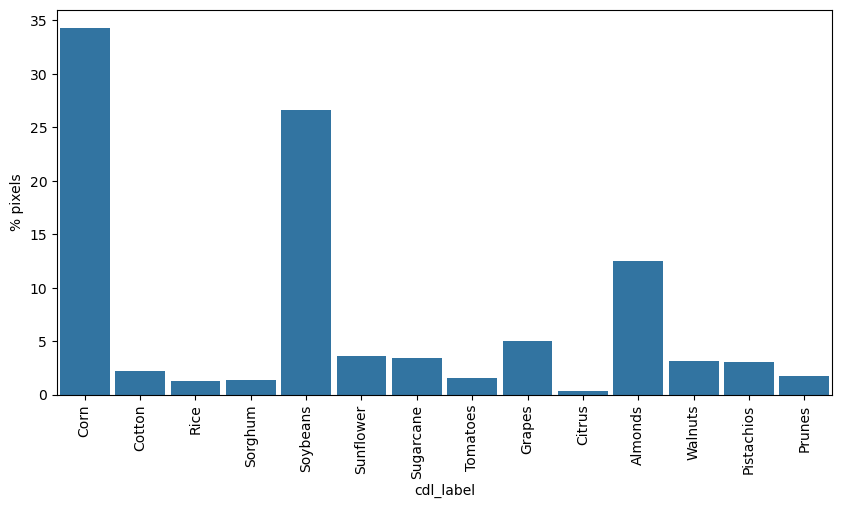

In [ ]:
# Attempt to balance the dataset a little bit? Not much difference 

display(df.set_index("cdl_label").loc[["Plums", "Prunes"]])
display(df.set_index("cdl_label").loc[["Oranges", "Citrus"]])
display(df.set_index("cdl_label").loc[["Sweet Corn", "Pop or Orn Corn", "Corn"]])
display(df.set_index("cdl_label").loc[["Dbl Crop WinWht/Sorghum", "Sorghum"]])

cdl_resample_classes = {
    212: 72, # Oranges -> Citrus
    220: 210, # Plums -> Prunes
    12: 1, # Sweet Corn -> Corn
    13: 1, # Pop or Orn Corn -> Corn
    236: 4 # DblCrop WinWht/Sorghum -> Sorghum
}
remap_df = df.copy()
remap_df["label_idx"] = remap_df.index.map(lambda x: cdl_resample_classes.get(x, x)) 
remap_df = remap_df.groupby("label_idx")["freq"].sum().to_frame()
remap_df["cdl_label"] = remap_df.index.map(CDL.classes)
remap_df = remap_df[remap_df["cdl_label"].isin(SpectralEarth.cdl_classes)]
remap_df["% pixels"] = (remap_df["freq"] / remap_df["freq"].sum()) * 100

fig, ax = plt.subplots(1,1,figsize = (10, 5))
plt.xticks(rotation=90, ha='center')
sns.barplot(remap_df, x = "cdl_label", y = "% pixels", width=0.9, ax = ax)
fig.savefig(SpectralEarth.local / "imagefolder" / "cdl_processed_label_dist.png")

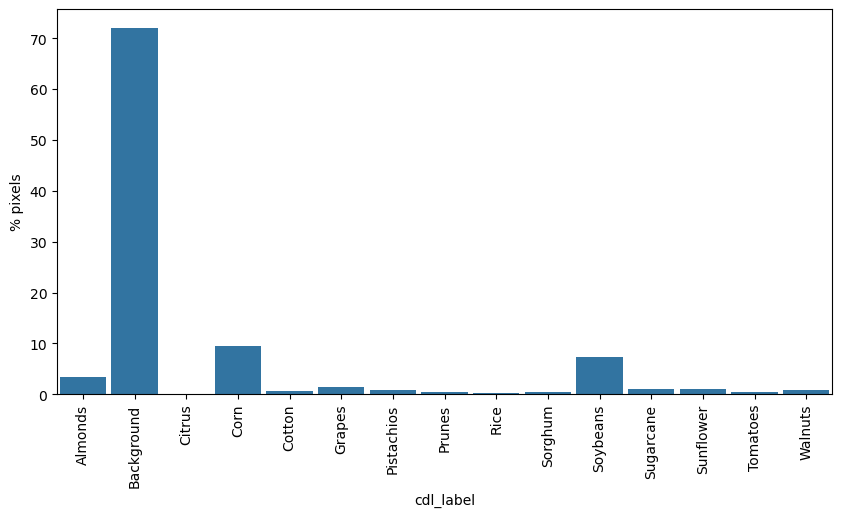

In [ ]:
# map everything else to background?
remap_df = df.copy()
remap_df["label_idx"] = remap_df.index.map(lambda x: cdl_resample_classes.get(x, x)) 
remap_df = remap_df.groupby("label_idx")["freq"].sum().to_frame()
remap_df["cdl_label"] = remap_df.index.map(CDL.classes)
remap_df["cdl_label"] = remap_df["cdl_label"].apply(lambda x: x if x in SpectralEarth.cdl_classes else "Background")

remap_df = remap_df.groupby("cdl_label")["freq"].sum().to_frame()
remap_df["% pixels"] = (remap_df["freq"] / remap_df["freq"].sum()) * 100
#remap_df = remap_df[remap_df["cdl_label"].isin(SpectralEarth.cdl_classes)]
fig, ax = plt.subplots(1,1,figsize = (10, 5))
plt.xticks(rotation=90, ha='center')
sns.barplot(remap_df, x = "cdl_label", y = "% pixels", width=0.9, ax = ax)
fig.savefig(SpectralEarth.local / "imagefolder" / "cdl_processed_label_dist_w_bg.png")

In [7]:
# Not many pixels with double crops 
dbl_crops_df = df[df["cdl_label"].str.startswith("Dbl")].set_index("cdl_label")
dbl_crops_df.loc["Total"] = [dbl_crops_df["freq"].sum(), dbl_crops_df["% pixels"].sum()]
dbl_crops_df

,freq,% pixels
cdl_label,,
Dbl Crop WinWht/Soybeans,122061.0,0.372501
Dbl Crop WinWht/Corn,38641.0,0.117923
Dbl Crop Oats/Corn,36206.0,0.110492
Dbl Crop Triticale/Corn,5850.0,0.017853
Dbl Crop Lettuce/Cantaloupe,3976.0,0.012134
Dbl Crop Lettuce/Cotton,1282.0,0.003912
Dbl Crop Lettuce/Barley,4425.0,0.013504
Dbl Crop WinWht/Sorghum,1940.0,0.005920
Dbl Crop Barley/Corn,391.0,0.001193


In [14]:
#df[df["cdl_label"].isin(SpectralEarth.cdl_class_str)].index

#df["label_idx"] = remap_df.index.map(lambda x: cdl_resample_classes.get(x, x)) 
cdl_df = df.copy()
cdl_df["label_idx"] = cdl_df.index.map(lambda x: x if x in SpectralEarth.cdl_class_idx else cdl_resample_classes.get(x, 0))
cdl_resampling = {x:y for x, y in zip(cdl_df.index, cdl_df["label_idx"])}
cdl_resampling_fn = np.vectorize(lambda x: cdl_resampling.get(x, x))
cdl_df

,freq,% pixels,cdl_label,label_idx
1,3128413,9.547159,Corn,1
2,200322,0.611334,Cotton,2
3,116600,0.355835,Rice,3
4,120782,0.368597,Sorghum,4
5,2431560,7.420532,Soybeans,5
...,...,...,...,...
247,5,0.000015,Turnips,0
248,61,0.000186,Eggplants,0
249,6,0.000018,Gourds,0
250,276,0.000842,Cranberries,0


[  0   4 255]
[  1   5  24  28  36  37  42  49  61  68  77 111 121 122 123 124 131 141
 142 143 152 176 190 195 205 229]


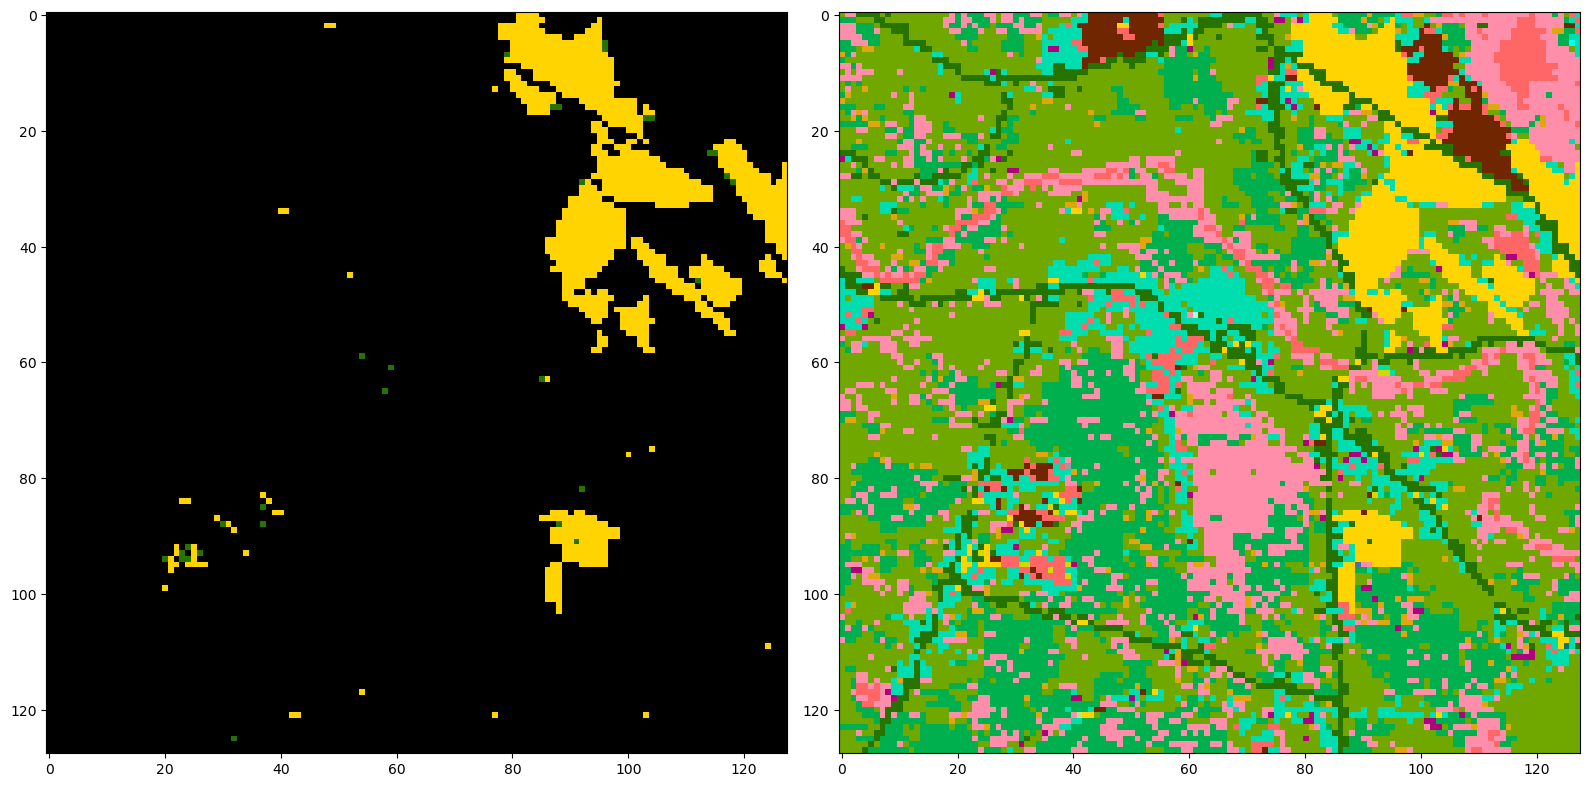

In [ ]:
cdl_cmap = ListedColormap([x for (_, x) in sorted(CDL.colors.items())], name = "cdl", N = 255)
se_cdl_cmap = SpectralEarth.get_cdl_colormap()

with h5py.File(SpectralEarth.local / "hdf5" / "spectral_earth_cdl.h5") as f:
    idx = np.random.randint(0, len(f["masks"]))
    mask, cdl_mask = f["masks"][idx], f["cdl_masks"][idx]

    print(np.unique(mask))
    print(np.unique(cdl_mask))

fig, (ax0, ax1) = plt.subplots(1, 2, figsize = (16, 8))
ax0.imshow(mask, cmap = se_cdl_cmap, vmin = 0, vmax = 14)
ax1.imshow(cdl_mask, cmap = cdl_cmap, vmin = 0, vmax = 255)
plt.tight_layout()


In [ ]:
hist_data: dict[int, int] = dict()
cdl_freq = np.zeros(shape = (100,), dtype = np.int64)

with h5py.File(SpectralEarth.local / "hdf5" / "top_1k_spectral_earth_nlcd.h5") as f:
    print(f.keys())
    for mask in tqdm(f["nlcd_masks"]):
        for value in mask.flatten().tolist():
            cdl_freq[value] += 1

<KeysViewHDF5 ['index', 'nlcd', 'nlcd_images', 'nlcd_masks']>


100%|██████████| 1000/1000 [00:04<00:00, 205.62it/s]


,num_pixels,% pixels,nlcd_label
11,1054694,6.437341,Open Water
12,5945,0.036285,Perennial Ice/Snow
21,1025129,6.256891,"Developed, Open Space"
22,1017513,6.210406,"Developed, Low Intensity"
23,847332,5.171704,"Developed, Medium Intensity"
24,354737,2.165143,"Developed, High Intensity"
31,753734,4.600427,Barren Land
41,1390781,8.488654,Deciduous Forest
42,1320328,8.058643,Evergreen Forest
43,998147,6.092206,Mixed Forest


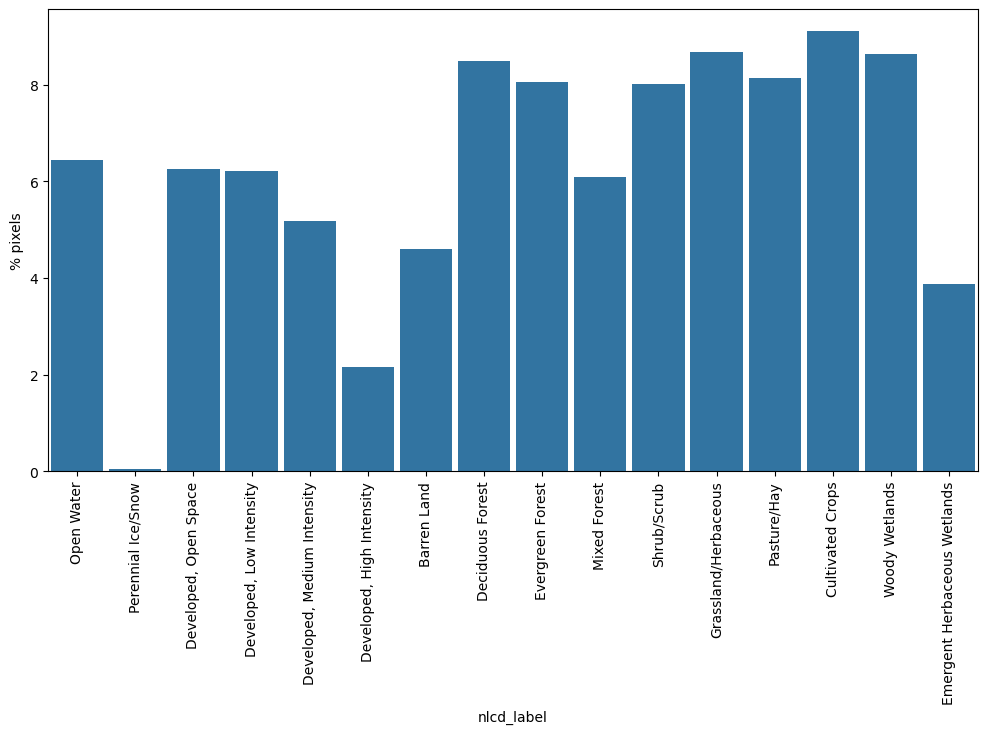

In [96]:
df = pd.DataFrame({"num_pixels": cdl_freq})
df = df[df["num_pixels"] > 0]
df["% pixels"] = (df["num_pixels"] / df["num_pixels"].sum()) * 100
df["nlcd_label"] = df.index.map(lambda x: NLCD.classes.get(x))

fig, ax = plt.subplots(1,1, figsize = (12, 6))
plt.xticks(rotation=90, ha='center')
sns.barplot(df, x = "nlcd_label", y = "% pixels", width=0.9, ax = ax)
#fig.savefig(SpectralEarth.local / "imagefolder" / "cdl_pixel_dist.png")

df

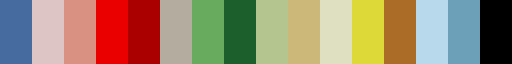

[ 0  1  2  3  4  5  6  7  8 10 11 13 14]


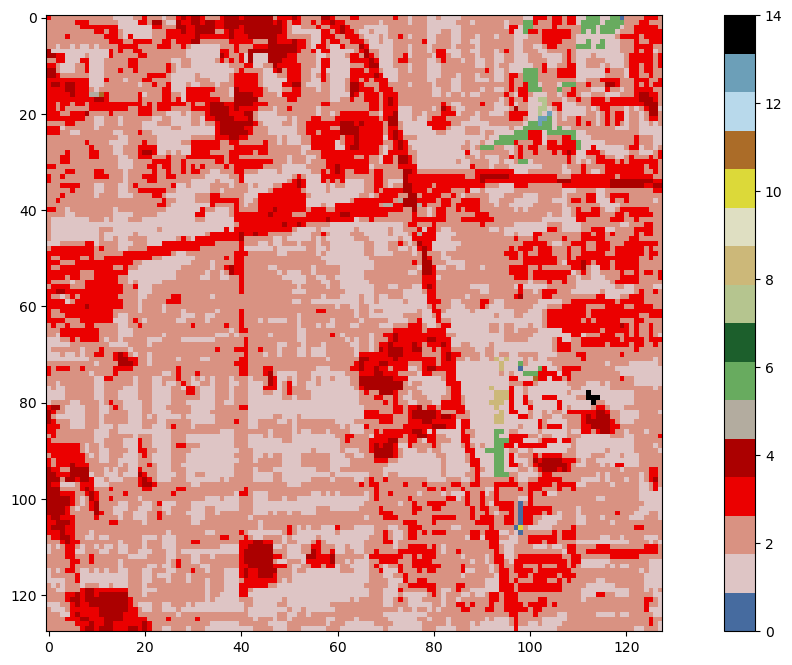

In [ ]:
nlcd_cmap = SpectralEarth.get_colormap("nlcd")
remap_fn = SpectralEarth.get_remap_fn("nlcd")
display(nlcd_cmap)

with h5py.File(SpectralEarth.local / "hdf5" / "top_1k_spectral_earth_nlcd.h5") as f:
    idx = np.random.randint(0, len(f["nlcd_masks"]))
    mask = f["nlcd_masks"][idx]
    mask = remap_fn(mask)
    print(np.unique(mask))

fig, ax0 = plt.subplots(1, 1, figsize = (16, 8))
plt.imshow(mask, cmap = nlcd_cmap)
plt.colorbar()


array([0, 2, 3], dtype=uint8)

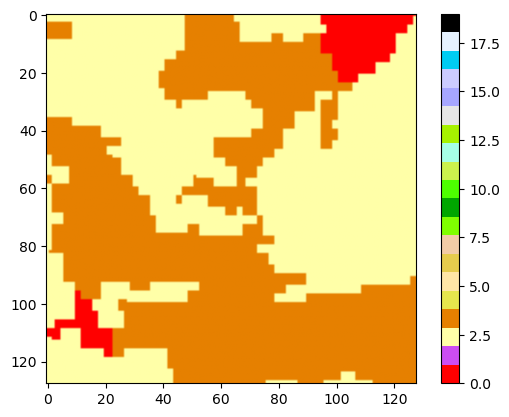

In [149]:
cmap = SpectralEarth.get_colormap("corine")

with h5py.File(SpectralEarth.local / "hdf5" / "spectral_earth_corine.h5") as f:
    idx = np.random.randint(0, len(f["masks"]))
    mask = f["masks"][idx]
    display(np.unique(mask))

plt.imshow(mask, cmap=cmap, vmin=0, vmax=19)
plt.colorbar()

In [ ]:
ds = SpectralEarth_CDL_Segmentation_HDF5()
image, mask, idx = ds[]
idx

np.int64(12)